# Sampling Methods for Statistical Inference

In this notebook, we'll explore various sampling methods used in statistical inference and machine learning. These techniques help us generate samples from complex distributions and estimate statistical properties.

## Learning Objectives
- Understand the importance of sampling methods in statistics
- Implement rejection sampling for generating samples from arbitrary distributions
- Explore Markov Chain Monte Carlo (MCMC) methods
- Visualize and analyze sampling results

In [1]:
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random

# Add the parent directory to the path so we can import our modules
sys.path.append('../..')
from phase0.statistics.sampling import RejectionSampling, ImportanceSampling, MetropolisHastings

# Set the style for our plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Introduction to Sampling Methods

Sampling methods are essential in statistics and machine learning for several reasons:

1. **Approximating complex distributions**: When we can't directly sample from a distribution, we can use these methods to generate approximate samples.
2. **Estimating statistical quantities**: We can estimate expectations, variances, and other properties of distributions.
3. **Bayesian inference**: Many Bayesian computations require samples from posterior distributions.
4. **Monte Carlo integration**: Calculating integrals that don't have closed-form solutions.

Let's explore several sampling methods, starting with rejection sampling.

## 2. Rejection Sampling

Rejection sampling is a basic technique for generating samples from a target distribution when we can only evaluate it up to a normalizing constant. The method works by:

1. Sampling from a proposal distribution that is easy to sample from
2. Accepting or rejecting samples based on their likelihood ratio

Let's implement rejection sampling to generate samples from a mixture of Gaussians.

In [2]:
# Define a target distribution: mixture of two Gaussians
def target_pdf(x):
    # Mixture of N(-2, 1) and N(2, 0.5) with weights 0.3 and 0.7
    return 0.3 * stats.norm.pdf(x, -2, 1) + 0.7 * stats.norm.pdf(x, 2, 0.5)

# Define a proposal distribution: uniform on [-5, 5]
def proposal_pdf(x):
    if -5 <= x <= 5:
        return 1/10  # Uniform density on [-5, 5]
    else:
        return 0

# Function to sample from the proposal distribution
def proposal_sampler():
    return random.uniform(-5, 5)

# Find a suitable value for M (upper bound on target_pdf / proposal_pdf)
x_range = np.linspace(-5, 5, 1000)
y_target = [target_pdf(x) for x in x_range]
y_proposal = [proposal_pdf(x) for x in x_range]
ratios = [t / p if p > 0 else 0 for t, p in zip(y_target, y_proposal)]
M = 1.2 * max(ratios)  # Add a safety margin

print(f"Using M = {M:.4f} for rejection sampling")

Using M = 6.7026 for rejection sampling


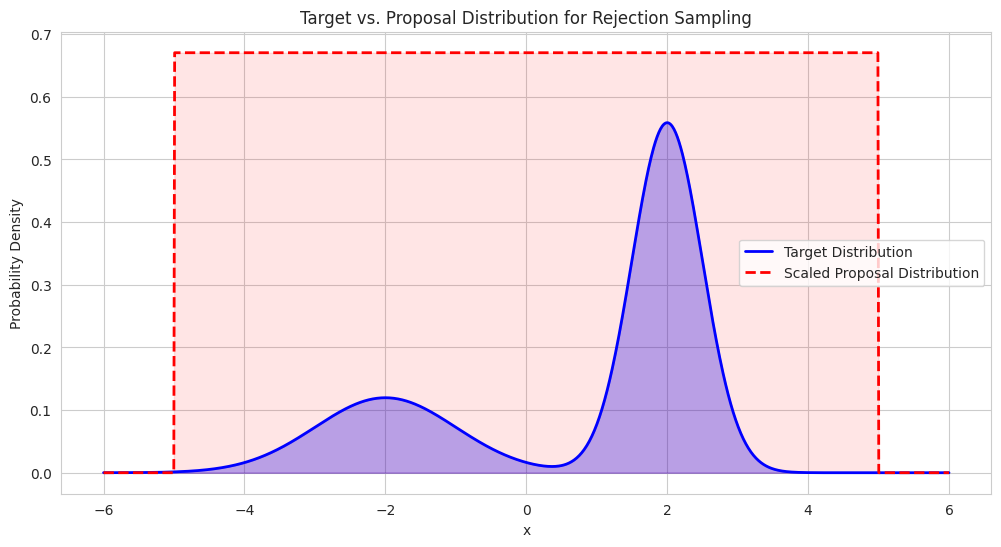

In [3]:
# Plot the target and proposal distributions
x = np.linspace(-6, 6, 1000)
y_target = [target_pdf(xi) for xi in x]
y_proposal = [M * proposal_pdf(xi) for xi in x]

plt.figure(figsize=(12, 6))
plt.plot(x, y_target, 'b-', linewidth=2, label='Target Distribution')
plt.plot(x, y_proposal, 'r--', linewidth=2, label='Scaled Proposal Distribution')
plt.fill_between(x, y_target, alpha=0.3, color='blue')
plt.fill_between(x, y_proposal, alpha=0.1, color='red')
plt.title('Target vs. Proposal Distribution for Rejection Sampling')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

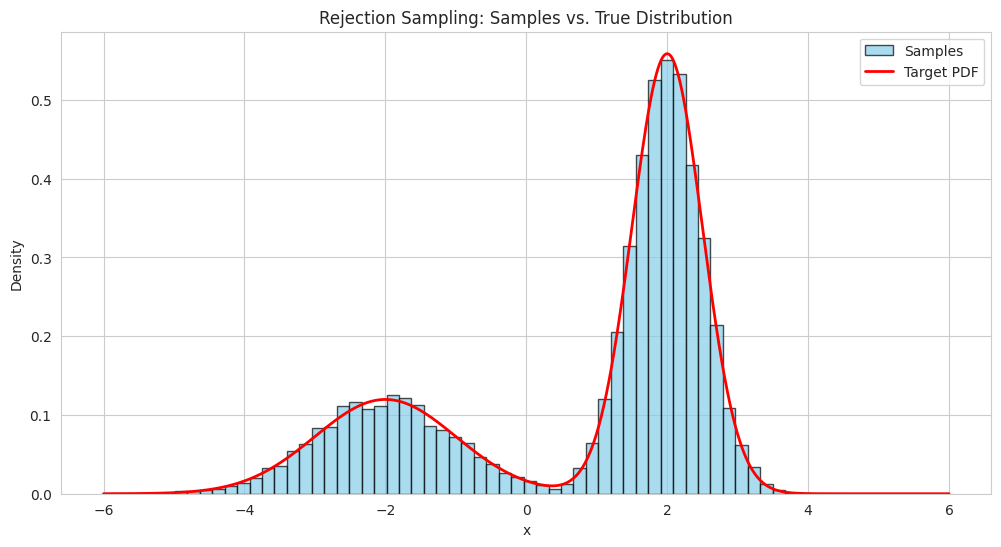

In [4]:
# Create the rejection sampler
rejection_sampler = RejectionSampling(target_pdf, proposal_pdf, proposal_sampler, M)

# Generate samples
samples = rejection_sampler.sample(10000)

# Plot a histogram of the samples against the true density
plt.figure(figsize=(12, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Samples')
plt.plot(x, y_target, 'r-', linewidth=2, label='Target PDF')
plt.title('Rejection Sampling: Samples vs. True Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### Exercise: Sampling from a Truncated Normal Distribution

Let's use rejection sampling to sample from a truncated normal distribution, which is a normal distribution restricted to a certain range.

In [5]:
# Define a truncated normal target distribution
def truncated_normal_pdf(x, mu=0, sigma=1, a=-1, b=2):
    """PDF of normal distribution truncated to [a, b]"""
    if a <= x <= b:
        # Unnormalized density
        return stats.norm.pdf(x, mu, sigma)
    else:
        return 0

# Define a uniform proposal on [a, b]
def uniform_proposal_pdf(x, a=-1, b=2):
    if a <= x <= b:
        return 1/(b-a)
    else:
        return 0

def uniform_proposal_sampler(a=-1, b=2):
    return random.uniform(a, b)

# Find M for rejection sampling
a, b = -1, 2
mu, sigma = 0, 1
x_range = np.linspace(a, b, 1000)
y_target = [truncated_normal_pdf(x, mu, sigma, a, b) for x in x_range]
y_proposal = [uniform_proposal_pdf(x, a, b) for x in x_range]
ratios = [t / p if p > 0 else 0 for t, p in zip(y_target, y_proposal)]
M_truncated = 1.2 * max(ratios)

print(f"Using M = {M_truncated:.4f} for truncated normal sampling")

Using M = 1.4362 for truncated normal sampling


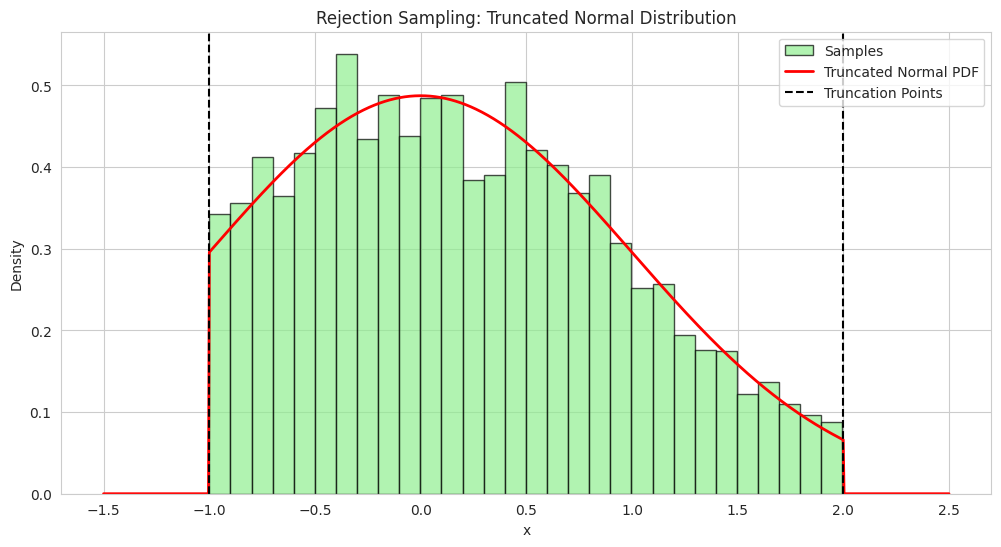

In [6]:
# Create a sampler for the truncated normal
truncated_sampler = RejectionSampling(
    lambda x: truncated_normal_pdf(x, mu, sigma, a, b),
    lambda x: uniform_proposal_pdf(x, a, b),
    lambda: uniform_proposal_sampler(a, b),
    M_truncated
)

# Generate samples
truncated_samples = truncated_sampler.sample(5000)

# Plot the results
x = np.linspace(a-0.5, b+0.5, 1000)
y_truncated = [truncated_normal_pdf(xi, mu, sigma, a, b) for xi in x]
# Normalize the PDF
normalization = stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma)
y_truncated = [y / normalization if a <= xi <= b else 0 for xi, y in zip(x, y_truncated)]

plt.figure(figsize=(12, 6))
plt.hist(truncated_samples, bins=30, density=True, alpha=0.7, color='lightgreen', edgecolor='black', label='Samples')
plt.plot(x, y_truncated, 'r-', linewidth=2, label='Truncated Normal PDF')
plt.axvline(a, color='k', linestyle='--', label='Truncation Points')
plt.axvline(b, color='k', linestyle='--')
plt.title('Rejection Sampling: Truncated Normal Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

## 3. Importance Sampling

Importance sampling is used to estimate expectations of functions under a target distribution by sampling from a different proposal distribution. This is especially useful when:

1. Directly sampling from the target distribution is difficult
2. We only care about estimating specific expectations, not generating samples

Let's use importance sampling to estimate the mean of a distribution.

In [7]:
# Target distribution: mixture of Gaussians (same as before)
def target_pdf(x):
    return 0.3 * stats.norm.pdf(x, -2, 1) + 0.7 * stats.norm.pdf(x, 2, 0.5)

# Proposal distribution: normal with mean 0 and std 3
def proposal_pdf(x):
    return stats.norm.pdf(x, 0, 3)

def proposal_sampler():
    return np.random.normal(0, 3)

# Create importance sampler
importance_sampler = ImportanceSampling(target_pdf, proposal_pdf, proposal_sampler)

# Function whose expectation we want to estimate: the identity function (to estimate mean)
def identity(x):
    return x

# Estimate the mean
estimated_mean, std_error = importance_sampler.estimate_expectation(identity, n_samples=10000)

print(f"Estimated mean: {estimated_mean:.4f} ± {std_error:.4f}")

# Calculate the true mean for comparison
true_mean = 0.3 * (-2) + 0.7 * 2
print(f"True mean: {true_mean:.4f}")

Estimated mean: 0.8162 ± 0.0003
True mean: 0.8000


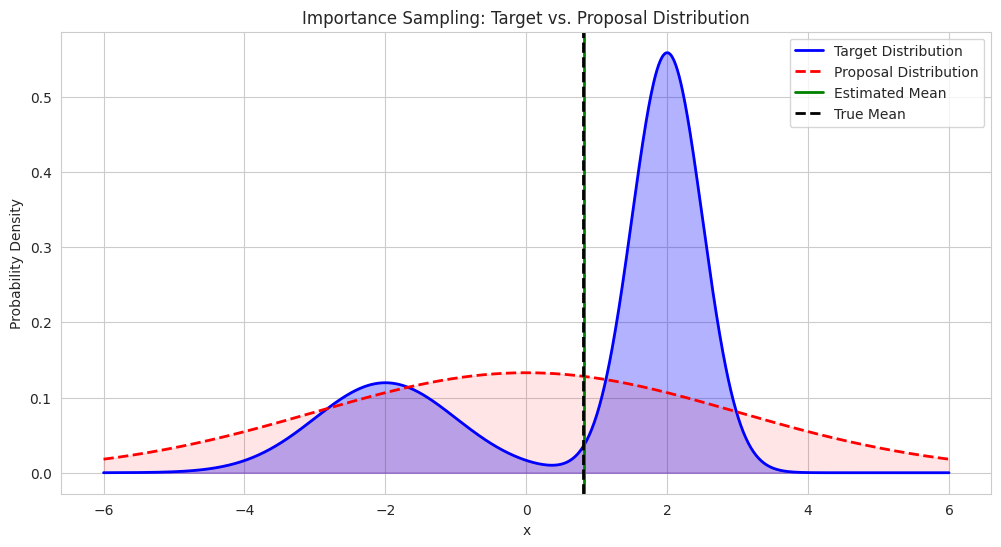

In [8]:
# Visualize the target and proposal distributions
x = np.linspace(-6, 6, 1000)
y_target = [target_pdf(xi) for xi in x]
y_proposal = [proposal_pdf(xi) for xi in x]

plt.figure(figsize=(12, 6))
plt.plot(x, y_target, 'b-', linewidth=2, label='Target Distribution')
plt.plot(x, y_proposal, 'r--', linewidth=2, label='Proposal Distribution')
plt.axvline(estimated_mean, color='g', linestyle='-', linewidth=2, label='Estimated Mean')
plt.axvline(true_mean, color='k', linestyle='--', linewidth=2, label='True Mean')
plt.fill_between(x, y_target, alpha=0.3, color='blue')
plt.fill_between(x, y_proposal, alpha=0.1, color='red')
plt.title('Importance Sampling: Target vs. Proposal Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()

## 4. Markov Chain Monte Carlo (MCMC)

MCMC methods generate samples by constructing a Markov chain whose stationary distribution is the target distribution. The most common MCMC algorithm is the Metropolis-Hastings algorithm.

Let's use our implementation to sample from a bimodal distribution.

In [9]:
# Target distribution: bimodal distribution
def bimodal_target(x):
    return np.exp(-0.5 * ((x - 2) / 0.6)**2) + np.exp(-0.5 * ((x + 2) / 0.6)**2)

# Proposal distribution: normal distribution centered at current point
def normal_proposal(x):
    return np.random.normal(x, 0.5)

# Create Metropolis-Hastings sampler
mh_sampler = MetropolisHastings(bimodal_target, normal_proposal, initial_state=0.0)

# Generate samples with burn-in and thinning
burn_in = 1000
n_samples = 10000
thin = 5
samples = mh_sampler.sample(n_samples, burn_in, thin)

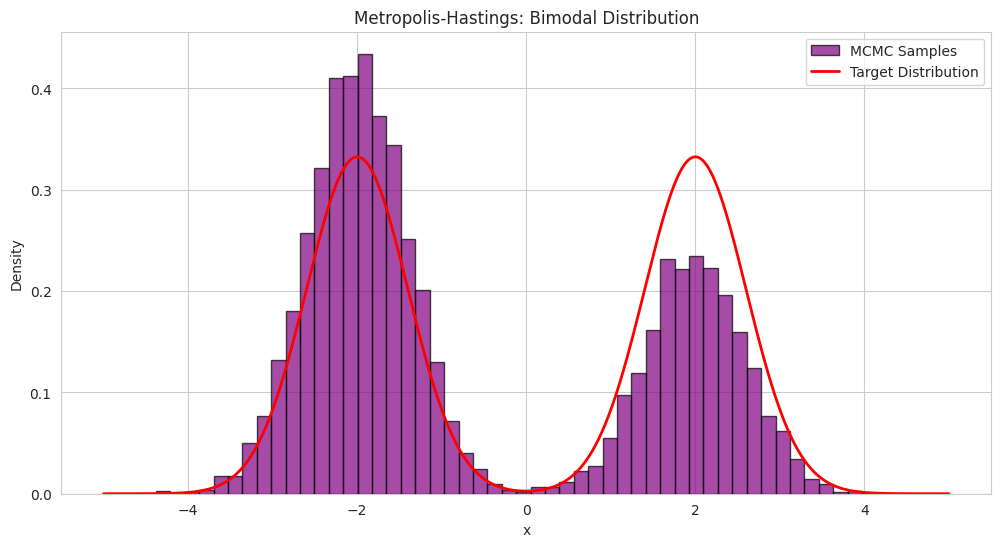

In [10]:
# Plot the target distribution and histogram of samples
x = np.linspace(-5, 5, 1000)
y = [bimodal_target(xi) for xi in x]
y = np.array(y) / np.trapz(y, x)  # Normalize

plt.figure(figsize=(12, 6))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black', label='MCMC Samples')
plt.plot(x, y, 'r-', linewidth=2, label='Target Distribution')
plt.title('Metropolis-Hastings: Bimodal Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

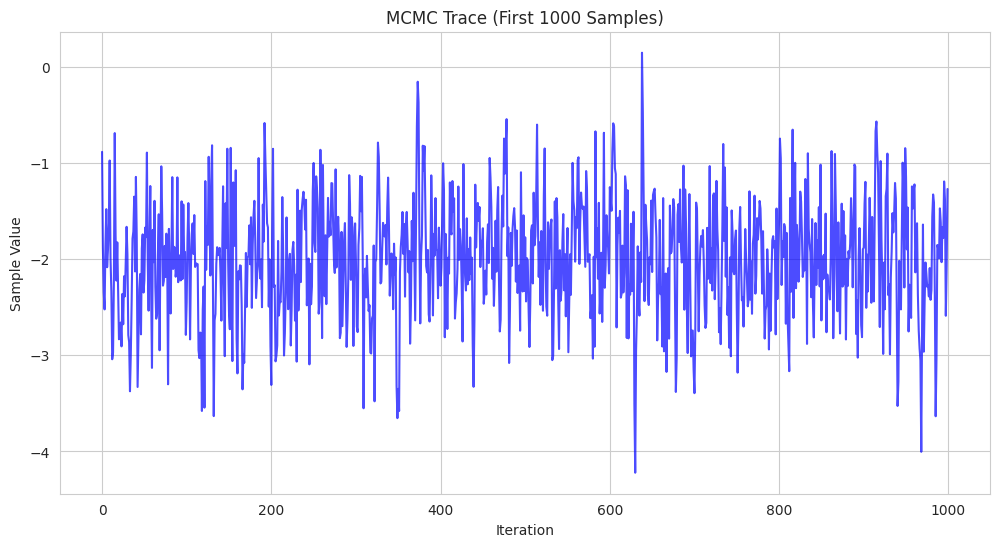

In [11]:
# Plot the trace of the Markov chain
plt.figure(figsize=(12, 6))
plt.plot(samples[:1000], 'b-', alpha=0.7)
plt.title('MCMC Trace (First 1000 Samples)')
plt.xlabel('Iteration')
plt.ylabel('Sample Value')
plt.grid(True)
plt.show()

### Assessing MCMC Convergence

When using MCMC methods, it's important to assess whether the chain has converged to the target distribution. Several techniques can be used:

1. **Visual inspection**: Plotting the trace and checking if it appears to be stationary
2. **Autocorrelation**: Checking how correlated samples are at different lags
3. **Running multiple chains**: Starting from different points and checking if they converge to the same distribution

Let's examine the autocorrelation of our MCMC samples:

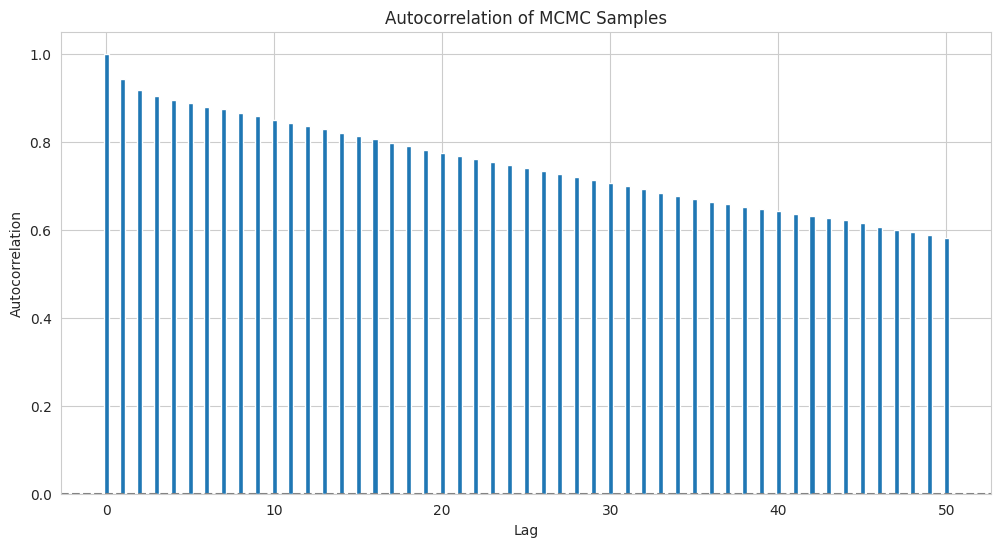

Estimated autocorrelation time: 75.24
Effective sample size: 133 (of 10000 samples)


In [12]:
# Calculate autocorrelation
def autocorrelation(x, max_lag=50):
    """Calculate autocorrelation for lags 0 to max_lag"""
    n = len(x)
    x = np.array(x) - np.mean(x)  # Mean-center the data
    
    # Normalize by variance
    norm = np.sum(x**2)
    
    # Calculate autocorrelation for each lag
    acorr = np.zeros(max_lag + 1)
    for lag in range(max_lag + 1):
        acorr[lag] = np.sum(x[:(n-lag)] * x[lag:]) / norm
        
    return acorr

# Calculate and plot autocorrelation
lags = 50
acorr = autocorrelation(samples, lags)

plt.figure(figsize=(12, 6))
plt.bar(range(lags+1), acorr, width=0.3)
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Autocorrelation of MCMC Samples')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# Estimate effective sample size
# Rough estimate using initial positive sequence
positive_acorr = acorr[acorr > 0]
tau = 1 + 2 * sum(positive_acorr[1:])
effective_sample_size = len(samples) / tau

print(f"Estimated autocorrelation time: {tau:.2f}")
print(f"Effective sample size: {effective_sample_size:.0f} (of {len(samples)} samples)")

## 5. Application: Sampling from a Posterior Distribution

Let's apply our sampling methods to a Bayesian inference problem. We'll estimate the posterior distribution of a parameter given some data.

In [13]:
# Simulate data from a normal distribution
np.random.seed(42)
true_mu = 5.0
sigma = 2.0
n_data = 20
data = np.random.normal(true_mu, sigma, n_data)

print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std dev: {np.std(data, ddof=1):.2f}")

# Define the posterior (up to a constant)
def log_posterior(mu, data=data, sigma=sigma):
    # Flat prior, so posterior is proportional to likelihood
    log_likelihood = -0.5 * np.sum(((data - mu) / sigma)**2)
    return log_likelihood

def posterior(mu, data=data, sigma=sigma):
    return np.exp(log_posterior(mu, data, sigma))

Sample mean: 4.66
Sample std dev: 1.92


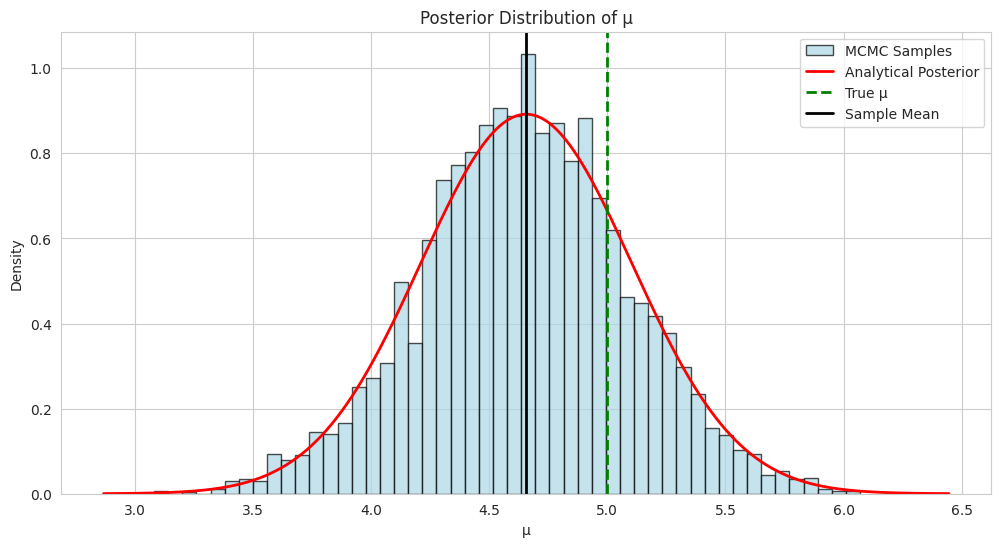

Analytical posterior mean: 4.6574
Analytical posterior std: 0.4472
MCMC posterior mean: 4.6515
MCMC posterior std: 0.4390
MCMC 95% credible interval: [3.7526, 5.5258]


In [14]:
# Create Metropolis-Hastings sampler for the posterior
def normal_proposal(mu):
    return np.random.normal(mu, 0.5)

posterior_sampler = MetropolisHastings(posterior, normal_proposal, initial_state=0.0)

# Generate samples
n_samples = 5000
burn_in = 1000
posterior_samples = posterior_sampler.sample(n_samples, burn_in)

# Plot the posterior samples
# Calculate analytical posterior for comparison
# With flat prior, posterior is N(sample_mean, sigma^2/n)
sample_mean = np.mean(data)
posterior_std = sigma / np.sqrt(n_data)

x = np.linspace(sample_mean - 4*posterior_std, sample_mean + 4*posterior_std, 1000)
y = stats.norm.pdf(x, sample_mean, posterior_std)

plt.figure(figsize=(12, 6))
plt.hist(posterior_samples, bins=50, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='MCMC Samples')
plt.plot(x, y, 'r-', linewidth=2, label='Analytical Posterior')
plt.axvline(true_mu, color='g', linestyle='--', linewidth=2, label='True µ')
plt.axvline(sample_mean, color='k', linestyle='-', linewidth=2, label='Sample Mean')
plt.title('Posterior Distribution of µ')
plt.xlabel('µ')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Calculate posterior statistics
mcmc_mean = np.mean(posterior_samples)
mcmc_std = np.std(posterior_samples)
mcmc_95ci = np.percentile(posterior_samples, [2.5, 97.5])

print(f"Analytical posterior mean: {sample_mean:.4f}")
print(f"Analytical posterior std: {posterior_std:.4f}")
print(f"MCMC posterior mean: {mcmc_mean:.4f}")
print(f"MCMC posterior std: {mcmc_std:.4f}")
print(f"MCMC 95% credible interval: [{mcmc_95ci[0]:.4f}, {mcmc_95ci[1]:.4f}]")

## Conclusion

In this notebook, we've explored various sampling methods used in statistical inference and machine learning:

1. **Rejection sampling**: A simple method for generating samples from arbitrary distributions
2. **Importance sampling**: Used to estimate expectations of functions under a target distribution
3. **Markov Chain Monte Carlo (MCMC)**: A family of methods for sampling from complex distributions

These techniques are essential for Bayesian inference, probabilistic modeling, and many other areas of statistics and machine learning. They allow us to work with complex distributions that we can't directly sample from, and to estimate properties of these distributions.